# PRCP-1022 Hospital Stay Prediction

## Objective

Build a Machine Learning model to predict the expected hospital stay category of patients using healthcare data.

The project focuses on analyzing patient and hospital-related factors that may influence the length of hospital stay and developing classification models to predict the patient's expected stay category.

## Tasks

- Data Analysis
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Model Development
- Model Evaluation
- Model Comparison
- Production Recommendation
- Challenges and Solutionsecommendation

In [1]:
# Ignore warnings

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Data manipulation

import pandas as pd
import numpy as np

In [3]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [5]:
# Encoding

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [6]:
# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [123]:
# Regression Models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor



In [8]:
# Display Settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [9]:
# Load the dataset

df = pd.read_csv("HealthCareAnalytics.csv")

In [10]:
df.head()

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50


In [11]:
df.tail()


,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
318433,318434,6,a,6,X,3,radiotherapy,Q,F,4.0,86499,23.0,Emergency,Moderate,3,41-50,4144,Nov-20
318434,318435,24,a,1,X,2,anesthesia,Q,E,4.0,325,8.0,Urgent,Moderate,4,81-90,6699,31-40
318435,318436,7,a,4,X,3,gynecology,R,F,4.0,125235,10.0,Emergency,Minor,3,71-80,4235,Nov-20
318436,318437,11,b,2,Y,3,anesthesia,Q,D,3.0,91081,8.0,Trauma,Minor,5,Nov-20,3761,Nov-20
318437,318438,19,a,7,Y,5,gynecology,Q,C,2.0,21641,8.0,Emergency,Minor,2,Nov-20,4752,0-10


In [12]:
df.shape

(318438, 18)

In [13]:
df.columns

Index(['case_id', 'Hospital_code', 'Hospital_type_code', 'City_Code_Hospital',
       'Hospital_region_code', 'Available_Extra_Rooms_in_Hospital',
       'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed_Grade',
       'patientid', 'City_Code_Patient', 'Type_of_Admission',
       'Severity_of_Illness', 'Visitors_with_Patient', 'Age',
       'Admission_Deposit', 'Stay'],
      dtype='str')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  str    
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  str    
 5   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  str    
 7   Ward_Type                          318438 non-null  str    
 8   Ward_Facility_Code                 318438 non-null  str    
 9   Bed_Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  313906 non-null

In [15]:
df.describe()

,case_id,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Visitors_with_Patient,Admission_Deposit
count,318438.000000,318438.000000,318438.000000,318438.000000,318325.000000,318438.000000,313906.000000,318438.000000,318438.000000
mean,159219.500000,18.318841,4.771717,3.197627,2.625807,65747.579472,7.251859,3.284099,4880.749392
std,91925.276848,8.633755,3.102535,1.168171,0.873146,37979.936440,4.745266,1.764061,1086.776254
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1800.000000
25%,79610.250000,11.000000,2.000000,2.000000,2.000000,32847.000000,4.000000,2.000000,4186.000000
50%,159219.500000,19.000000,5.000000,3.000000,3.000000,65724.500000,8.000000,3.000000,4741.000000
75%,238828.750000,26.000000,7.000000,4.000000,3.000000,98470.000000,8.000000,4.000000,5409.000000
max,318438.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11008.000000


In [16]:
df["Stay"].value_counts()

Stay
21-30                 87491
Nov-20                78139
31-40                 55159
51-60                 35018
0-10                  23604
41-50                 11743
71-80                 10254
More than 100 Days     6683
81-90                  4838
91-100                 2765
61-70                  2744
Name: count, dtype: int64

In [17]:
#EXploratory Data Analysis

#Checking Missing values
df.isnull().sum()

case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available_Extra_Rooms_in_Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed_Grade                             113
patientid                               0
City_Code_Patient                    4532
Type_of_Admission                       0
Severity_of_Illness                     0
Visitors_with_Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64

In [18]:
#Checking missing values percentage
(df.isnull().sum()/len(df))*100

case_id                              0.000000
Hospital_code                        0.000000
Hospital_type_code                   0.000000
City_Code_Hospital                   0.000000
Hospital_region_code                 0.000000
Available_Extra_Rooms_in_Hospital    0.000000
Department                           0.000000
Ward_Type                            0.000000
Ward_Facility_Code                   0.000000
Bed_Grade                            0.035486
patientid                            0.000000
City_Code_Patient                    1.423197
Type_of_Admission                    0.000000
Severity_of_Illness                  0.000000
Visitors_with_Patient                0.000000
Age                                  0.000000
Admission_Deposit                    0.000000
Stay                                 0.000000
dtype: float64

In [19]:
#Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [20]:
#Counting Numerical and Categorical Columns
numerical_columns=df.select_dtypes(include=['int64','float64']).columns
categorical_columns=df.select_dtypes(include=['object']).columns
print("Numerical Columns")
print(numerical_columns)

print()

print("Categorical Columns")
print(categorical_columns)

Numerical Columns
Index(['case_id', 'Hospital_code', 'City_Code_Hospital',
       'Available_Extra_Rooms_in_Hospital', 'Bed_Grade', 'patientid',
       'City_Code_Patient', 'Visitors_with_Patient', 'Admission_Deposit'],
      dtype='str')

Categorical Columns
Index(['Hospital_type_code', 'Hospital_region_code', 'Department', 'Ward_Type',
       'Ward_Facility_Code', 'Type_of_Admission', 'Severity_of_Illness', 'Age',
       'Stay'],
      dtype='str')


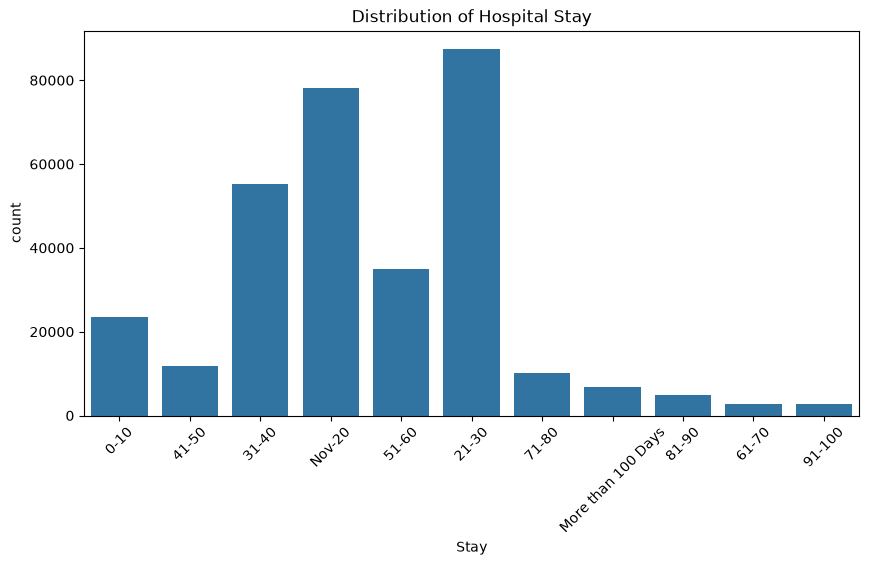

In [21]:
#Plot the target variable
plt.figure(figsize=(10,5))
sns.countplot(x='Stay', data=df)
plt.title("Distribution of Hospital Stay")
plt.xticks(rotation=45)
plt.show()

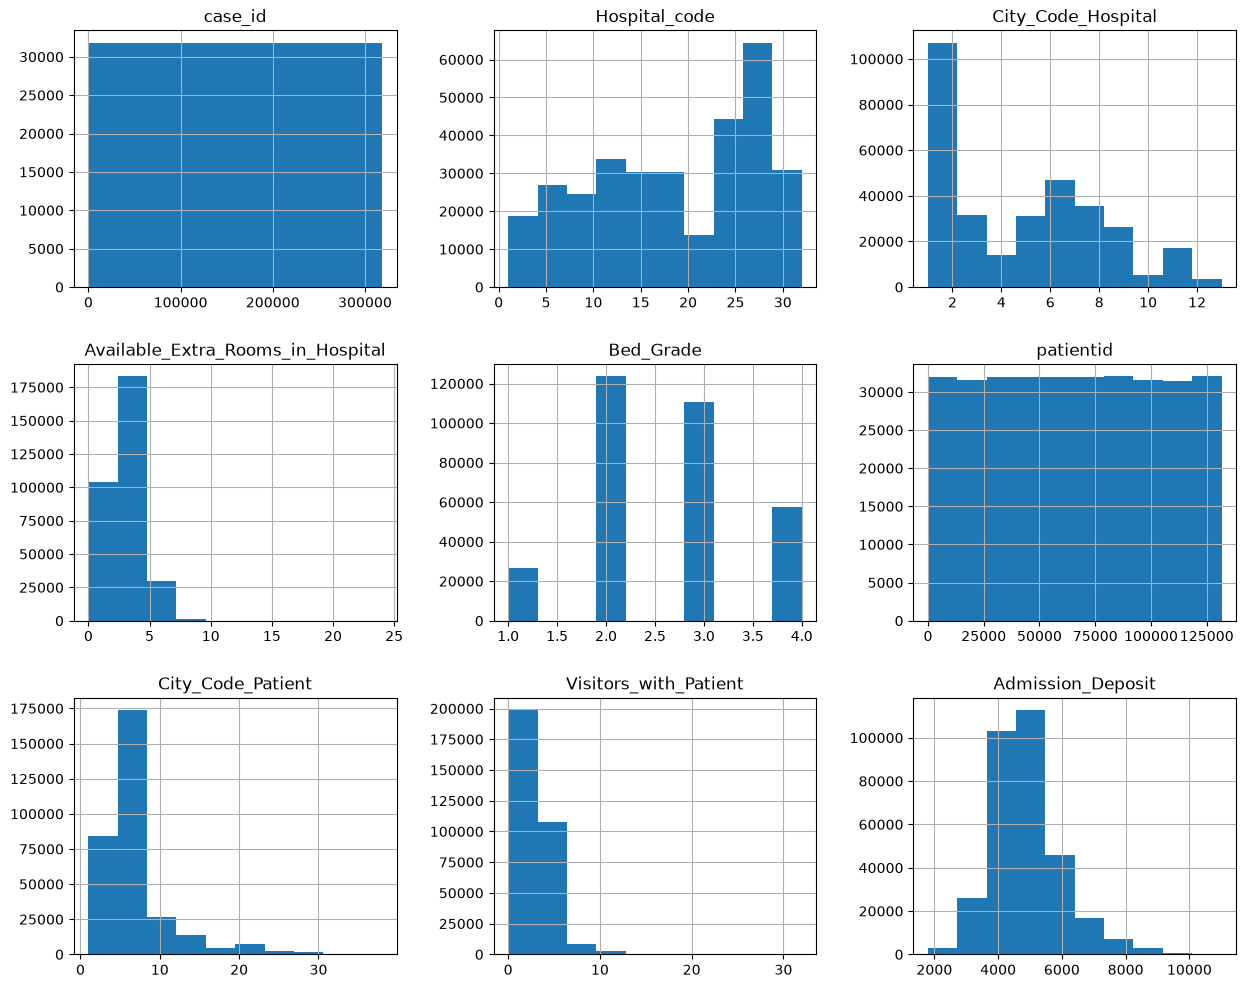

In [22]:
#Distribution of Numerical features
df.hist(figsize=(15,12))
plt.show()

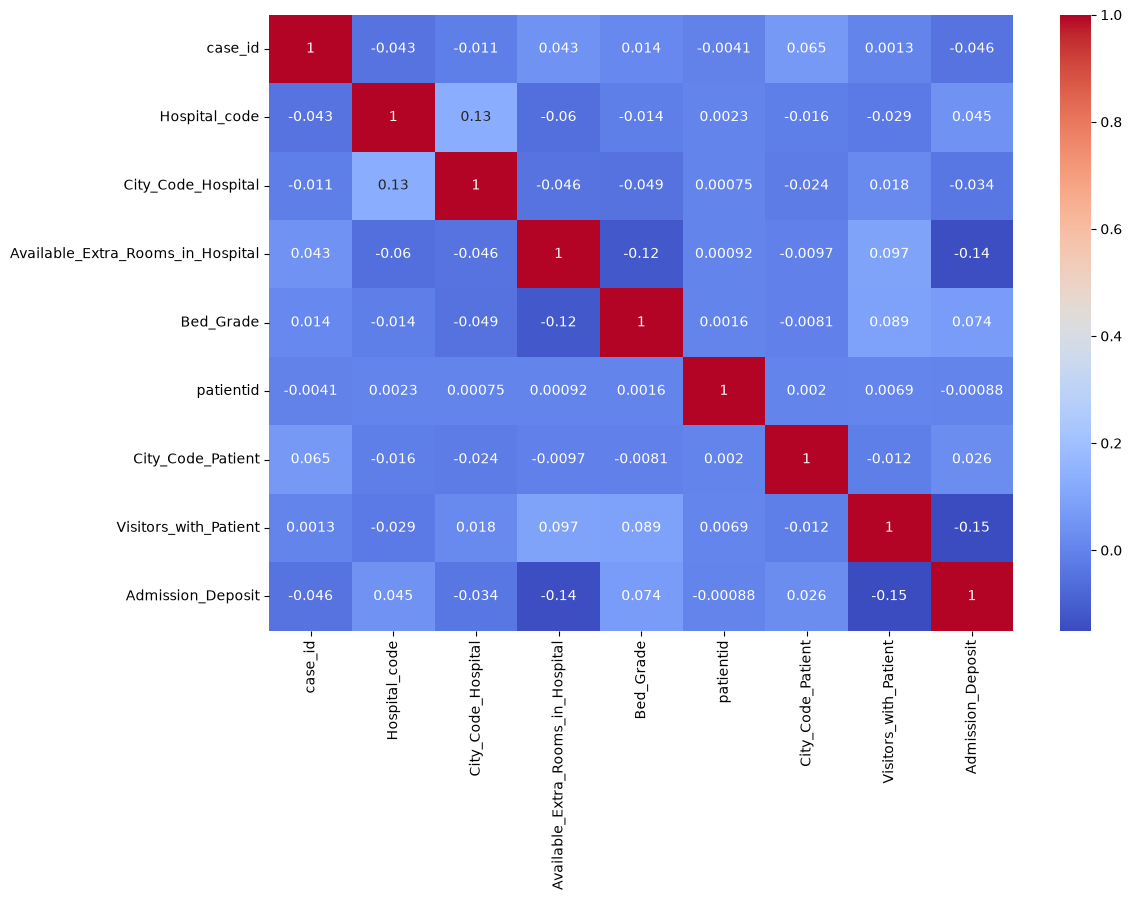

In [23]:
#Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

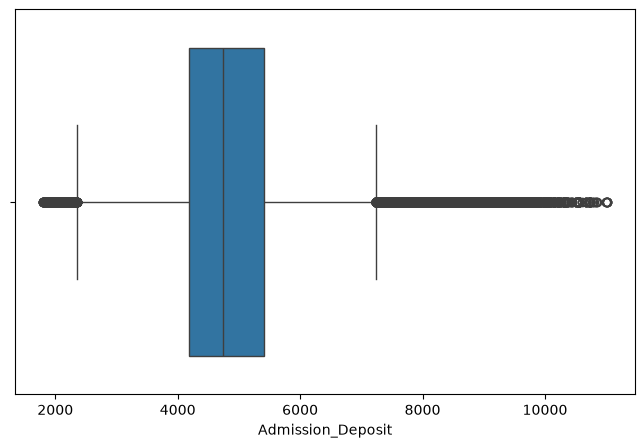

In [24]:
#BoxPlot for outlier detection
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Admission_Deposit'])
plt.show()

In [25]:
#Check Missing Values Again

missing = df.isnull().sum()
missing = missing[missing > 0]
missing


Bed_Grade             113
City_Code_Patient    4532
dtype: int64

In [26]:
#Checking Missing value percentage

missing_percentage=(df.isnull().sum()/len(df))*100
missing_percentage=missing_percentage[missing_percentage>0]
missing_percentage


Bed_Grade            0.035486
City_Code_Patient    1.423197
dtype: float64

In [27]:
#Duplicates

df.duplicated().sum()

np.int64(0)

In [28]:
#Data Types

df.dtypes

case_id                                int64
Hospital_code                          int64
Hospital_type_code                       str
City_Code_Hospital                     int64
Hospital_region_code                     str
Available_Extra_Rooms_in_Hospital      int64
Department                               str
Ward_Type                                str
Ward_Facility_Code                       str
Bed_Grade                            float64
patientid                              int64
City_Code_Patient                    float64
Type_of_Admission                        str
Severity_of_Illness                      str
Visitors_with_Patient                  int64
Age                                      str
Admission_Deposit                      int64
Stay                                     str
dtype: object

In [29]:
#Unique Values
for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 Hospital_type_code
<StringArray>
['c', 'e', 'b', 'a', 'f', 'd', 'g']
Length: 7, dtype: str

 Hospital_region_code
<StringArray>
['Z', 'X', 'Y']
Length: 3, dtype: str

 Department
<StringArray>
['radiotherapy', 'anesthesia', 'gynecology', 'TB & Chest disease', 'surgery']
Length: 5, dtype: str

 Ward_Type
<StringArray>
['R', 'S', 'Q', 'P', 'T', 'U']
Length: 6, dtype: str

 Ward_Facility_Code
<StringArray>
['F', 'E', 'D', 'B', 'A', 'C']
Length: 6, dtype: str

 Type_of_Admission
<StringArray>
['Emergency', 'Trauma', 'Urgent']
Length: 3, dtype: str

 Severity_of_Illness
<StringArray>
['Extreme', 'Moderate', 'Minor']
Length: 3, dtype: str

 Age
<StringArray>
[ '51-60',  '71-80',  '31-40',  '41-50',  '81-90',  '61-70',  '21-30',
 'Nov-20',   '0-10', '91-100']
Length: 10, dtype: str

 Stay
<StringArray>
[              '0-10',              '41-50',              '31-40',
             'Nov-20',              '51-60',              '21-30',
              '71-80', 'More than 100 Days',             

Handling Missing Values

In [30]:
#Checking Missing Values

df.isnull().sum()[df.isnull().sum()>0]

Bed_Grade             113
City_Code_Patient    4532
dtype: int64

In [31]:
#Filling Bed grade Column
df['Bed_Grade'] = df['Bed_Grade'].fillna(
    df['Bed_Grade'].median()
)


In [32]:
#Filling City code patient column
df['City_Code_Patient'] = df['City_Code_Patient'].fillna(
    df['City_Code_Patient'].mode()[0]
)


In [33]:
#verifying Missing Values
print("\nMissing values after treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0])



Missing values after treatment:
Series([], dtype: int64)


In [34]:
#Verifying The Dataset Shape

df.shape

(318438, 18)

## Missing Value Treatment

Missing values were identified during the data-quality analysis.

- `Bed Grade`: Missing values were replaced using the median because the feature is numerical and the median is less sensitive to extreme values.
- `City_Code_Patient`: Missing values were replaced using the mode because it represents a categorical city code.
- The dataset was rechecked after imputation to ensure that missing values were handled successfully.
- Patient records were retained instead of removing rows with missing values.

-----------------FEATURE ENGINEERING--------------------


In [35]:
#Examining the age column

df['Age'].value_counts()

df['Age']=df['Age'].replace('Nov-20', '11-20')
df['Age'].value_counts()


Age
41-50     63749
31-40     63639
51-60     48514
21-30     40843
71-80     35792
61-70     33687
11-20     16768
81-90      7890
0-10       6254
91-100     1302
Name: count, dtype: int64

In [36]:
age_mapping = {
    '0-10': 5,
    '11-20': 15,
    '21-30': 25,
    '31-40': 35,
    '41-50': 45,
    '51-60': 55,
    '61-70': 65,
    '71-80': 75,
    '81-90': 85,
    '91-100': 95
}

df['Age_Mid'] = df['Age'].map(age_mapping)

#Comparing original and mapped values
df[['Age', 'Age_Mid']].head(20)


,Age,Age_Mid
0,51-60,55
1,51-60,55
2,51-60,55
3,51-60,55
4,51-60,55
5,51-60,55
6,51-60,55
7,51-60,55
8,51-60,55
9,51-60,55


In [37]:
#Checking For Mapping Failures
df['Age_Mid'].isnull().sum()

np.int64(0)

In [38]:
df['Age_Mid'].unique()

array([55, 75, 35, 45, 85, 65, 25, 15,  5, 95])

In [39]:
#Understanding the stay target

df['Stay'].unique()


<StringArray>
[              '0-10',              '41-50',              '31-40',
             'Nov-20',              '51-60',              '21-30',
              '71-80', 'More than 100 Days',              '81-90',
              '61-70',             '91-100']
Length: 11, dtype: str

In [40]:
df['Stay'] = df['Stay'].replace('Nov-20', '11-20')
df['Stay'].unique()

<StringArray>
[              '0-10',              '41-50',              '31-40',
              '11-20',              '51-60',              '21-30',
              '71-80', 'More than 100 Days',              '81-90',
              '61-70',             '91-100']
Length: 11, dtype: str

In [41]:
df['Stay'].value_counts()

Stay
21-30                 87491
11-20                 78139
31-40                 55159
51-60                 35018
0-10                  23604
41-50                 11743
71-80                 10254
More than 100 Days     6683
81-90                  4838
91-100                 2765
61-70                  2744
Name: count, dtype: int64

In [42]:
stay_mapping = {
    '0-10': 0,
    '11-20': 1,
    '21-30': 2,
    '31-40': 3,
    '41-50': 4,
    '51-60': 5,
    '61-70': 6,
    '71-80': 7,
    '81-90': 8,
    '91-100': 9,
    'More than 100 Days': 10
}

df['Stay_Label'] = df['Stay'].map(stay_mapping)

In [43]:
df[['Stay', 'Stay_Label']].head(20)

,Stay,Stay_Label
0,0-10,0
1,41-50,4
2,31-40,3
3,41-50,4
4,41-50,4
5,11-20,1
6,0-10,0
7,41-50,4
8,51-60,5
9,31-40,3


In [44]:
df['Stay_Label'].isnull().sum()

np.int64(0)

In [45]:
#Final target Verification
df[['Stay', 'Stay_Label']].value_counts().sort_index()

Stay                Stay_Label
0-10                0             23604
11-20               1             78139
21-30               2             87491
31-40               3             55159
41-50               4             11743
51-60               5             35018
61-70               6              2744
71-80               7             10254
81-90               8              4838
91-100              9              2765
More than 100 Days  10             6683
Name: count, dtype: int64

In [46]:
df.shape

(318438, 20)

-----------CATEGORICAL ENCODING------------

In [47]:
#Encoding Categorical Features

categorical_columns= df.select_dtypes(include='object').columns
print(categorical_columns)


Index(['Hospital_type_code', 'Hospital_region_code', 'Department', 'Ward_Type',
       'Ward_Facility_Code', 'Type_of_Admission', 'Severity_of_Illness', 'Age',
       'Stay'],
      dtype='str')


In [48]:
#Decidding Which Columns to Encode
df.select_dtypes(include='object').nunique()

Hospital_type_code       7
Hospital_region_code     3
Department               5
Ward_Type                6
Ward_Facility_Code       6
Type_of_Admission        3
Severity_of_Illness      3
Age                     10
Stay                    11
dtype: int64

In [49]:
#Removing Original Age and Stay Columns
df_model=df.drop(columns=['Age','Stay'])

In [50]:
#Identifying Ctegorical Columns in df_model
categorical_columns = df_model.select_dtypes(include='object').columns
print(categorical_columns)

Index(['Hospital_type_code', 'Hospital_region_code', 'Department', 'Ward_Type',
       'Ward_Facility_Code', 'Type_of_Admission', 'Severity_of_Illness'],
      dtype='str')


In [51]:
#Using One Hot Encoding Technique To Convert Categorical Values into Numerical Values

df_model=pd.get_dummies(
    df_model,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [52]:
df_model.head()

,case_id,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Visitors_with_Patient,Admission_Deposit,Age_Mid,Stay_Label,Hospital_type_code_b,Hospital_type_code_c,Hospital_type_code_d,Hospital_type_code_e,Hospital_type_code_f,Hospital_type_code_g,Hospital_region_code_Y,Hospital_region_code_Z,Department_anesthesia,Department_gynecology,Department_radiotherapy,Department_surgery,Ward_Type_Q,Ward_Type_R,Ward_Type_S,Ward_Type_T,Ward_Type_U,Ward_Facility_Code_B,Ward_Facility_Code_C,Ward_Facility_Code_D,Ward_Facility_Code_E,Ward_Facility_Code_F,Type_of_Admission_Trauma,Type_of_Admission_Urgent,Severity_of_Illness_Minor,Severity_of_Illness_Moderate
0,1,8,3,3,2.0,31397,7.0,2,4911,55,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
1,2,2,5,2,2.0,31397,7.0,2,5954,55,4,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0
2,3,10,1,2,2.0,31397,7.0,2,4745,55,3,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0
3,4,26,2,2,2.0,31397,7.0,2,7272,55,4,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0
4,5,26,2,2,2.0,31397,7.0,2,5558,55,4,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0


In [53]:
df_model.shape

(318438, 37)

In [54]:
#Verifying That No Object Columns Remain
df_model.select_dtypes(include='object').columns

Index([], dtype='str')

In [55]:
#Seperating Features and Target
# X=Input features
X=df_model.drop(columns=['Stay_Label'])

#y=Target
y=df_model['Stay_Label']

In [56]:
#Verifying X and Y
print("X shape:",X.shape)
print("y shape:", y.shape)

X shape: (318438, 36)
y shape: (318438,)


In [57]:
print("Target classes:")
print(y.unique())



Target classes:
[ 0  4  3  1  5  2  7 10  8  6  9]


## Categorical Feature Encoding

The dataset contains several categorical variables such as hospital type, hospital region, department, ward type, admission type, and severity of illness.

The original `Age` and `Stay` columns were removed from the modeling dataset after creating the engineered `Age_Mid` feature and encoded `Stay_Label` target.

One-hot encoding was applied to the remaining categorical variables to convert them into numerical features suitable for machine learning algorithms. `drop_first=True` was used to reduce redundant dummy variables.

The resulting dataset contains only numerical features and is ready for train-test splitting.

---------------TRAIN-TEST SPLIT----------------

In [58]:
#Checking X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

#Splitting the Dataset
X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#Checking the Shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)



X shape: (318438, 36)
y shape: (318438,)
X_train: (254750, 36)
X_test : (63688, 36)
y_train: (254750,)
y_test : (63688,)


In [59]:
#Verify Target Distribution
print("Training target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training target distribution:
Stay_Label
0     0.074124
1     0.245382
2     0.274752
3     0.173217
4     0.036875
5     0.109967
6     0.008616
7     0.032200
8     0.015195
9     0.008683
10    0.020989
Name: proportion, dtype: float64

Testing target distribution:
Stay_Label
0     0.074127
1     0.245384
2     0.274746
3     0.173219
4     0.036883
5     0.109974
6     0.008620
7     0.032204
8     0.015183
9     0.008683
10    0.020977
Name: proportion, dtype: float64


## Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio.

The training dataset is used to train the machine learning models, while the testing dataset is kept separate to evaluate how well the trained models generalize to unseen patient records.

Stratified sampling was used to maintain a similar distribution of hospital stay categories in both the training and testing datasets. A random state of 42 was used to ensure reproducibility.

In [60]:
#Checking Class Imbalance
class_counts=y_train.value_counts().sort_index()
class_counts

Stay_Label
0     18883
1     62511
2     69993
3     44127
4      9394
5     28014
6      2195
7      8203
8      3871
9      2212
10     5347
Name: count, dtype: int64

In [61]:
#Calculating Percentages
class_percentage=(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
class_percentage

Stay_Label
0      7.41
1     24.54
2     27.48
3     17.32
4      3.69
5     11.00
6      0.86
7      3.22
8      1.52
9      0.87
10     2.10
Name: proportion, dtype: float64

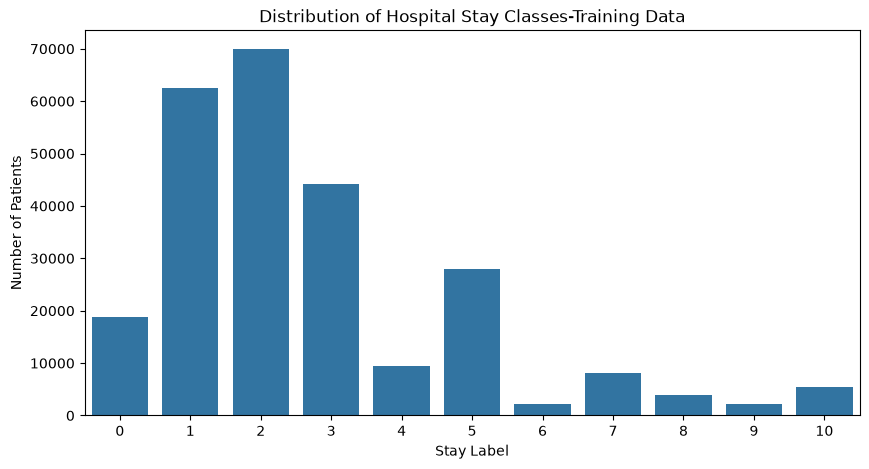

In [62]:
#Visualize class distribution
plt.figure(figsize=(10,5))
sns.countplot(x=y_train)
plt.title("Distribution of Hospital Stay Classes-Training Data")
plt.xlabel("Stay Label")
plt.ylabel("Number of Patients")
plt.show()

In [63]:
#Create a clear summary table
class_distribution=pd.DataFrame({
    'Count':y_train.value_counts().sort_index(),
    'Percentage':(
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})
class_distribution

,Count,Percentage
Stay_Label,,
0,18883,7.41
1,62511,24.54
2,69993,27.48
3,44127,17.32
4,9394,3.69
5,28014,11.00
6,2195,0.86
7,8203,3.22
8,3871,1.52


## Class Imbalance Analysis

The distribution of the target variable was analyzed after the train-test split to determine whether the hospital stay categories were balanced.

The frequency and percentage of each stay class were calculated and visualized. Since differences in class frequencies can influence model predictions, model performance will not be evaluated using accuracy alone.

Precision, recall, F1-score, and the confusion matrix will also be considered during model evaluation. In particular, macro-averaged F1-score will help evaluate performance across both frequent and less frequent stay categories.

Resampling techniques were not applied at this stage because baseline model performance should first be established before deciding whether additional imbalance-handling techniques are necessary.

----------------MACHINE LEARNING MODELS-----------------
----------MODEL 1- DECISION TREE CLASSIFIER-------------

In [64]:
#Building the Machine Learning Model
from sklearn.tree import DecisionTreeClassifier

In [65]:
dt_model=DecisionTreeClassifier(
    random_state=42
)

In [66]:
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [67]:
y_pred_dt=dt_model.predict(X_test)

In [68]:
#Checking Accuracy
from sklearn.metrics import accuracy_score
dt_accuracy=accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.30168948624544656


In [69]:
#Evaluating the decision tree
#1.Classification report
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred_dt,
    digits=4
))

              precision    recall  f1-score   support

           0     0.1834    0.1824    0.1829      4721
           1     0.3485    0.3447    0.3466     15628
           2     0.3833    0.3776    0.3804     17498
           3     0.2505    0.2533    0.2519     11032
           4     0.0646    0.0681    0.0663      2349
           5     0.3195    0.3171    0.3183      7004
           6     0.0307    0.0310    0.0308       549
           7     0.1554    0.1648    0.1600      2051
           8     0.2368    0.2554    0.2458       967
           9     0.1119    0.1193    0.1155       553
          10     0.3794    0.3862    0.3828      1336

    accuracy                         0.3017     63688
   macro avg     0.2240    0.2273    0.2256     63688
weighted avg     0.3031    0.3017    0.3024     63688



In [70]:
#Storing the Macro F1 Score
from sklearn.metrics import f1_score
dt_macro_f1=f1_score(
    y_test,
    y_pred_dt,
    average='macro'
)
dt_weighted_f1=f1_score(
    y_test,
    y_pred_dt,
    average='weighted'
)
print("Decision Tree Macro F1:", dt_macro_f1)
print("Decision Tree Weighted F1:", dt_weighted_f1)


Decision Tree Macro F1: 0.22557113457386035
Decision Tree Weighted F1: 0.3023956782894387


<Axes: >

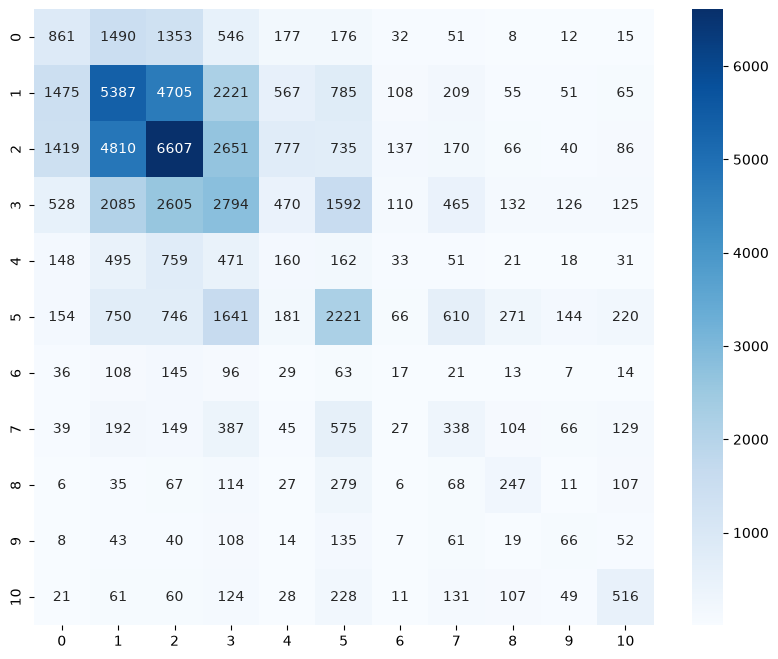

In [71]:
#Creating Confusion_matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

In [72]:
#Save the first model results
dt_results = {
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Macro F1': dt_macro_f1,
    'Weighted F1': dt_weighted_f1
}

dt_results

{'Model': 'Decision Tree',
 'Accuracy': 0.30168948624544656,
 'Macro F1': 0.22557113457386035,
 'Weighted F1': 0.3023956782894387}

----------MODEL-2 RANDOM FOREST----------------

In [73]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [74]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [75]:
y_pred_rf = rf_model.predict(X_test)

In [76]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.41229116945107397


In [77]:
rf_macro_f1 = f1_score(
    y_test,
    y_pred_rf,
    average='macro'
)

rf_weighted_f1 = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print("Random Forest Macro F1:", rf_macro_f1)
print("Random Forest Weighted F1:", rf_weighted_f1)

Random Forest Macro F1: 0.2814337397403514
Random Forest Weighted F1: 0.3867414253801284


In [78]:
rf_results = {
    'Model': 'Random Forest',
    'Accuracy': rf_accuracy,
    'Macro F1': rf_macro_f1,
    'Weighted F1': rf_weighted_f1
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.41229116945107397,
 'Macro F1': 0.2814337397403514,
 'Weighted F1': 0.3867414253801284}

Model 3: Gradient Boosting Classifier
51}

In [79]:
from sklearn.ensemble import GradientBoostingClassifier

In [85]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [86]:
gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [111]:
y_pred = gb_model.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.4120870493656576

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.11      0.17      4721
           1       0.42      0.49      0.45     15628
           2       0.42      0.66      0.52     17498
           3       0.39      0.17      0.23     11032
           4       0.11      0.00      0.00      2349
           5       0.38      0.54      0.45      7004
           6       0.18      0.00      0.01       549
           7       0.30      0.01      0.02      2051
           8       0.33      0.23      0.27       967
           9       0.09      0.00      0.01       553
          10       0.52      0.40      0.45      1336

    accuracy                           0.41     63688
   macro avg       0.32      0.24      0.23     63688
weighted avg       0.39      0.41      0.37     63688


Confusion Matrix:
[[  500  2429  1728    42     1    19     0     0     0     2     0]
 [  270  7709  6373   649     2   620     2   

In [98]:
y_pred_proba = gb_model.predict_proba(X_test)

In [99]:
from sklearn.metrics import roc_auc_score

# Get probabilities for all classes
y_pred_proba = gb_model.predict_proba(X_test)

# Calculate multiclass ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    y_pred_proba,
    multi_class="ovr",
    average="weighted"
)

print("Multiclass ROC-AUC Score:", roc_auc)

Multiclass ROC-AUC Score: 0.7487812206276


-----Class imabalance observation----

In [95]:
print("Training class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Training class distribution:
Stay_Label
0     18883
1     62511
2     69993
3     44127
4      9394
5     28014
6      2195
7      8203
8      3871
9      2212
10     5347
Name: count, dtype: int64

Test class distribution:
Stay_Label
0      4721
1     15628
2     17498
3     11032
4      2349
5      7004
6       549
7      2051
8       967
9       553
10     1336
Name: count, dtype: int64


In [96]:
print("Number of classes:", y_train.nunique())
print("Classes:", sorted(y_train.unique()))

Number of classes: 11
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


----Model4 - Balanced Random forest--------

In [100]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [101]:
y_pred_rf = rf_model.predict(X_test)

In [102]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.38377716367290543


In [103]:
from sklearn.metrics import classification_report

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.43      0.31      4721
           1       0.43      0.42      0.42     15628
           2       0.45      0.47      0.46     17498
           3       0.37      0.20      0.26     11032
           4       0.10      0.09      0.09      2349
           5       0.39      0.53      0.45      7004
           6       0.15      0.04      0.07       549
           7       0.26      0.17      0.21      2051
           8       0.37      0.39      0.38       967
           9       0.42      0.12      0.19       553
          10       0.51      0.54      0.53      1336

    accuracy                           0.38     63688
   macro avg       0.33      0.31      0.31     63688
weighted avg       0.39      0.38      0.38     63688



In [104]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[2030 1449  948  132   97   42    4    9    3    3    4]
 [2588 6504 4268  954  360  784   28   92   15    9   26]
 [2058 4755 8212 1111  696  439   39   75   52    8   53]
 [ 876 1585 2990 2224  433 2502   24  261   66   19   52]
 [ 279  390  926  255  200  212   16   25   17    6   23]
 [ 311  366  634  945  113 3727   12  420  267   28  181]
 [  52   65  182   66   36   78   23   14   14    1   18]
 [  67   66  115  203   22 1008    8  352   57   11  142]
 [  25   20   18   46    8  318    1   26  375    4  126]
 [  14   13   34   47    8  240    1   45   15   68   68]
 [  39    6   24   46   11  276    2   58  142    5  727]]


In [105]:
y_pred_proba_rf = rf_model.predict_proba(X_test)

In [106]:
from sklearn.metrics import roc_auc_score

roc_auc_rf = roc_auc_score(
    y_test,
    y_pred_proba_rf,
    multi_class="ovr",
    average="weighted"
)

print("Random Forest Multiclass ROC-AUC:", roc_auc_rf)

Random Forest Multiclass ROC-AUC: 0.7464571805225741


In [107]:
from sklearn.metrics import f1_score

rf_macro_f1 = f1_score(y_test, y_pred_rf, average="macro")
rf_weighted_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Macro F1:", rf_macro_f1)
print("Random Forest Weighted F1:", rf_weighted_f1)

Random Forest Macro F1: 0.30518772900370644
Random Forest Weighted F1: 0.3758677600488209


In [108]:
from sklearn.metrics import accuracy_score, f1_score

rf_balanced_accuracy = accuracy_score(y_test, y_pred_rf)
rf_balanced_macro_f1 = f1_score(y_test, y_pred_rf, average="macro")
rf_balanced_weighted_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Balanced Random Forest Accuracy:",
      rf_balanced_accuracy)

print("Balanced Random Forest Macro F1:",
      rf_balanced_macro_f1)

print("Balanced Random Forest Weighted F1:",
      rf_balanced_weighted_f1)

Balanced Random Forest Accuracy: 0.38377716367290543
Balanced Random Forest Macro F1: 0.30518772900370644
Balanced Random Forest Weighted F1: 0.3758677600488209


In [109]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.24      0.43      0.31      4721
           1       0.43      0.42      0.42     15628
           2       0.45      0.47      0.46     17498
           3       0.37      0.20      0.26     11032
           4       0.10      0.09      0.09      2349
           5       0.39      0.53      0.45      7004
           6       0.15      0.04      0.07       549
           7       0.26      0.17      0.21      2051
           8       0.37      0.39      0.38       967
           9       0.42      0.12      0.19       553
          10       0.51      0.54      0.53      1336

    accuracy                           0.38     63688
   macro avg       0.33      0.31      0.31     63688
weighted avg       0.39      0.38      0.38     63688



## Model Comparison and Selection

The dataset contains 11 hospital stay categories with significant class imbalance. Therefore, model selection was based not only on accuracy but also on macro F1-score and weighted F1-score.

The balanced Random Forest model improved the macro F1-score compared with the baseline Random Forest, indicating better overall performance across the different stay categories. However, the overall accuracy decreased slightly.

The final model will therefore be selected by considering the trade-off between overall predictive accuracy and balanced performance across all target classes.

In [113]:
# Gradient Boosting predictions
y_pred_gb = gb_model.predict(X_test)

In [115]:
from sklearn.metrics import accuracy_score, f1_score

# Balanced Random Forest
balanced_rf_accuracy = accuracy_score(y_test, y_pred_rf)
balanced_rf_macro_f1 = f1_score(y_test, y_pred_rf, average="macro")
balanced_rf_weighted_f1 = f1_score(y_test, y_pred_rf, average="weighted")

# Gradient Boosting
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_macro_f1 = f1_score(y_test, y_pred_gb, average="macro")
gb_weighted_f1 = f1_score(y_test, y_pred_gb, average="weighted")

# Comparison
model_comparison = pd.DataFrame({
    "Model": [
        "Balanced Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        balanced_rf_accuracy,
        gb_accuracy
    ],
    "Macro F1": [
        balanced_rf_macro_f1,
        gb_macro_f1
    ],
    "Weighted F1": [
        balanced_rf_weighted_f1,
        gb_weighted_f1
    ]
})

model_comparison

,Model,Accuracy,Macro F1,Weighted F1
0,Balanced Random Forest,0.383777,0.305188,0.375868
1,Gradient Boosting,0.412087,0.233814,0.369227


## Final Model Selection

The models were compared using Accuracy, Macro F1-score, and Weighted F1-score.

The Gradient Boosting Classifier achieved the highest accuracy of 41.21%. However, because the target variable contains 11 imbalanced hospital stay categories, accuracy alone is not sufficient for model selection.

The Balanced Random Forest achieved a higher Macro F1-score of 0.3052 compared with 0.2338 for Gradient Boosting. It also achieved a slightly higher Weighted F1-score of 0.3759 compared with 0.3692.

Therefore, the Balanced Random Forest was selected as the final model because it provides better balanced performance across the different hospital stay categories.

## Final Model Evaluation

In [116]:
# Final predictions using the selected Balanced Random Forest
final_predictions = rf_model.predict(X_test)

In [117]:
from sklearn.metrics import classification_report

print("Final Model Classification Report:")
print(classification_report(y_test, final_predictions))

Final Model Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.43      0.31      4721
           1       0.43      0.42      0.42     15628
           2       0.45      0.47      0.46     17498
           3       0.37      0.20      0.26     11032
           4       0.10      0.09      0.09      2349
           5       0.39      0.53      0.45      7004
           6       0.15      0.04      0.07       549
           7       0.26      0.17      0.21      2051
           8       0.37      0.39      0.38       967
           9       0.42      0.12      0.19       553
          10       0.51      0.54      0.53      1336

    accuracy                           0.38     63688
   macro avg       0.33      0.31      0.31     63688
weighted avg       0.39      0.38      0.38     63688



In [118]:
from sklearn.metrics import confusion_matrix

final_cm = confusion_matrix(y_test, final_predictions)

print("Final Model Confusion Matrix:")
print(final_cm)

Final Model Confusion Matrix:
[[2030 1449  948  132   97   42    4    9    3    3    4]
 [2588 6504 4268  954  360  784   28   92   15    9   26]
 [2058 4755 8212 1111  696  439   39   75   52    8   53]
 [ 876 1585 2990 2224  433 2502   24  261   66   19   52]
 [ 279  390  926  255  200  212   16   25   17    6   23]
 [ 311  366  634  945  113 3727   12  420  267   28  181]
 [  52   65  182   66   36   78   23   14   14    1   18]
 [  67   66  115  203   22 1008    8  352   57   11  142]
 [  25   20   18   46    8  318    1   26  375    4  126]
 [  14   13   34   47    8  240    1   45   15   68   68]
 [  39    6   24   46   11  276    2   58  142    5  727]]


In [119]:
from sklearn.metrics import roc_auc_score

final_probabilities = rf_model.predict_proba(X_test)

final_roc_auc = roc_auc_score(
    y_test,
    final_probabilities,
    multi_class="ovr",
    average="weighted"
)

print("Final Model ROC-AUC:", final_roc_auc)

Final Model ROC-AUC: 0.7464571805225741


In [120]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
8,Admission_Deposit,0.142305
0,case_id,0.138625
5,patientid,0.136189
7,Visitors_with_Patient,0.108721
9,Age_Mid,0.079065
6,City_Code_Patient,0.076194
3,Available_Extra_Rooms_in_Hospital,0.050679
4,Bed_Grade,0.041153
1,Hospital_code,0.040798
35,Severity_of_Illness_Moderate,0.020813


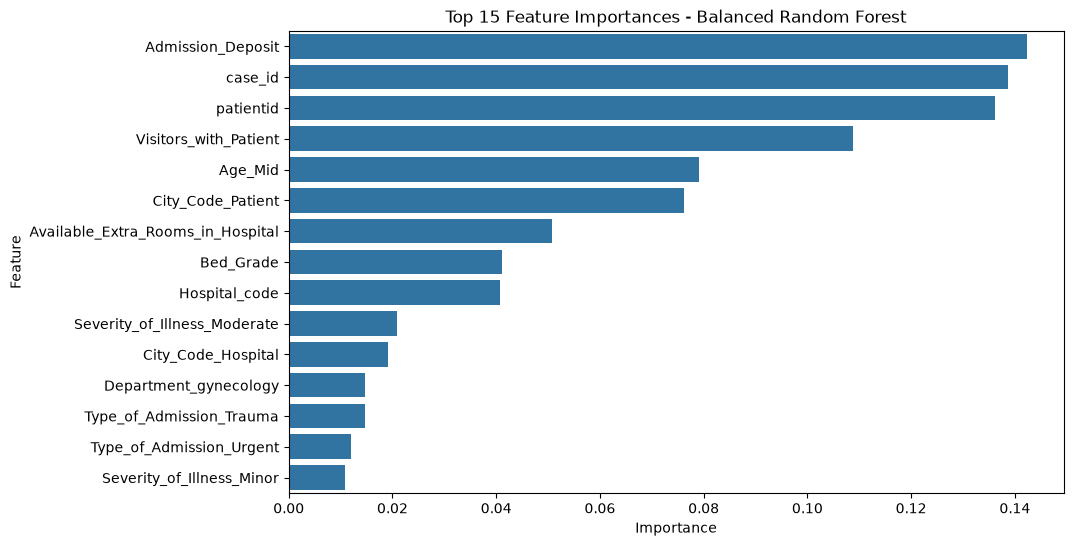

In [121]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Balanced Random Forest")
plt.show()

## Conclusion 


The Hospital Stay Prediction project developed a machine learning classification system to predict the expected hospital stay category of patients.

The dataset was cleaned and preprocessed by handling missing values, correcting inconsistent categorical values, performing feature engineering, and encoding categorical variables.

Multiple classification models were evaluated, including Decision Tree, Random Forest, Gradient Boosting, and Balanced Random Forest.

Because the target variable contains 11 imbalanced hospital stay categories, model selection was based on Accuracy, Precision, Recall, Macro F1-score, Weighted F1-score, and ROC-AUC.

The Balanced Random Forest was selected as the final model because it achieved better balanced performance across the different hospital stay categories, particularly based on the Macro F1-score.

## Recommendations and Future Scope

- Collect more data for underrepresented hospital stay categories.
- Monitor class-wise model performance after deployment.
- Retrain the model periodically using new hospital data.
- Perform further hyperparameter tuning to improve minority-class performance.
- Evaluate advanced ensemble and boosting techniques in future work.
- Deploy the model as a web application or REST API for practical use.

## Challenges Faced and Solutions

### 1. Missing Values

The dataset contained missing values in `Bed_Grade` and `City_Code_Patient`.

- `Bed_Grade` had 113 missing values.
- `City_Code_Patient` had 4,532 missing values.

Median imputation was applied to `Bed_Grade` because it is a numerical variable and the median is less sensitive to extreme values. Mode imputation was applied to `City_Code_Patient` because it represents a categorical city code.

This approach allowed the patient records to be retained instead of deleting rows. After treatment, no missing values remained. :contentReference[oaicite:3]{index=3}

### 2. Inconsistent Category in Age

The `Age` column contained the value `Nov-20`, which was interpreted as an incorrect representation of the `11-20` age group.

The value was corrected to `11-20` before converting the age ranges into numerical midpoint values.

### 3. Target Variable Encoding

The original `Stay` column contained categorical hospital stay ranges. These categories were converted into numerical labels from 0 to 10 to make them suitable for classification algorithms.

### 4. Categorical Variables

Several categorical features such as hospital type, hospital region, department, ward type, admission type, severity of illness, and age required encoding.

One-hot encoding was used to convert categorical variables into numerical features suitable for machine learning models. :contentReference[oaicite:4]{index=4}

### 5. Class Imbalance

The target variable contained 11 hospital stay categories with substantial differences in frequency. For example, class 2 represented 27.48% of the training data, while class 6 represented only 0.86%.

Because of this imbalance, accuracy alone was not considered sufficient. Precision, recall, F1-score, and confusion matrix were also considered.

A balanced Random Forest using `class_weight="balanced"` was evaluated to improve performance across minority classes. :contentReference[oaicite:5]{index=5}

### 6. Model Selection

Different classification algorithms produced different trade-offs between overall accuracy and balanced class performance.

Therefore, model selection was based on multiple metrics, particularly Macro F1-score, because it gives equal importance to all 11 hospital stay categories.

## Production Recommendation

The Balanced Random Forest was selected as the recommended model for production among the evaluated models.

Although Gradient Boosting achieved a higher overall accuracy of 41.21%, the Balanced Random Forest achieved a higher Macro F1-score of 0.3052 compared with 0.2338 for Gradient Boosting.

Since the target variable is highly imbalanced, Macro F1-score provides a more meaningful measure of performance across both majority and minority hospital stay categories.

Therefore, the Balanced Random Forest is recommended as the preferred baseline production model.

Before deployment in a real hospital environment, further validation, hyperparameter tuning, monitoring, and testing on more recent patient data would be required.